In [9]:
import pandas as pd

In [10]:
import pandas as pd

# Load the three datasets
base = pd.read_csv('base_iphone.csv')
gni = pd.read_csv('gni.csv')
premium = pd.read_csv('premium_iphone.csv')

# Remove completely empty rows from the base dataset
base = base.dropna()

# Clean the GNI year column
gni['YEAR'] = gni['YEAR'].str.extract(r'(\d{4})').astype(int)
gni = gni.rename(columns={'YEAR': 'Year'})

# Make sure base year is an integer
base['Year'] = base['Year'].astype(int)

# Merge base iPhone data with GNI
df = base.merge(gni, on='Year', how='left')

# Clean the merged dataset's year
df['Year'] = df['Year'].astype(int)

df.head()

,iPhone,Year,Indian_Launch_price INR,GNI Per Capita
0,iPhone 5,2012,45500.0,"76,854.98"
1,iPhone 5s,2013,53500.0,"85,610.32"
2,iPhone 6,2014,53500.0,"93,886.64"
3,iPhone 6s,2015,62000.0,"102,498.82"
4,iPhone 7,2016,60000.0,"113,213.53"


In [47]:
pd.set_option('display.max_rows' , None)
df


,iPhone,Year,Indian_Launch_price INR,GNI Per Capita
0,iPhone 5,2012,45500.0,"76,854.98"
1,iPhone 5s,2013,53500.0,"85,610.32"
2,iPhone 6,2014,53500.0,"93,886.64"
3,iPhone 6s,2015,62000.0,"102,498.82"
4,iPhone 7,2016,60000.0,"113,213.53"
5,iPhone 8,2017,64000.0,"124,334.48"
6,iPhone X,2017,89000.0,"124,334.48"
7,iPhone XR,2018,76900.0,"136,014.41"
8,iPhone 11,2019,64900.0,"143,340.85"
9,iPhone 12,2020,79900.0,"139,648.95"


In [48]:
premium_df = premium.merge(gni, on='Year', how='left')

premium_df

,iPhone,Year,India_Launch_Price_INR,GNI Per Capita
0,iPhone 11 Pro Max,2019,109900,"143,340.85"
1,iPhone 12 Pro Max,2020,129900,"139,648.95"
2,iPhone 13 Pro Max,2021,129900,"164,895.53"
3,iPhone 14 Pro Max,2022,139900,"180,629.30"
4,iPhone 15 Pro Max,2023,159900,"198,682.41"
5,iPhone 16 Pro Max,2024,144900,"216,398.31"
6,iPhone 17 Pro Max,2025,149900,"233,055.23"
7,iPhone Duo,2026,299900,NaN


In [49]:
df.columns
df

,iPhone,Year,Indian_Launch_price INR,GNI Per Capita
0,iPhone 5,2012,45500.0,"76,854.98"
1,iPhone 5s,2013,53500.0,"85,610.32"
2,iPhone 6,2014,53500.0,"93,886.64"
3,iPhone 6s,2015,62000.0,"102,498.82"
4,iPhone 7,2016,60000.0,"113,213.53"
5,iPhone 8,2017,64000.0,"124,334.48"
6,iPhone X,2017,89000.0,"124,334.48"
7,iPhone XR,2018,76900.0,"136,014.41"
8,iPhone 11,2019,64900.0,"143,340.85"
9,iPhone 12,2020,79900.0,"139,648.95"


In [13]:
df = base.merge(gni, on='Year', how='left')

df['Year'] = pd.to_numeric(df['Year'], errors='coerce').astype(int)

df['GNI Per Capita'] = pd.to_numeric(
    df['GNI Per Capita'].astype(str).str.replace(',', ''),
    errors='coerce'
)
df

,iPhone,Year,Indian_Launch_price INR,GNI Per Capita
0,iPhone 5,2012,45500.0,76854.98
1,iPhone 5s,2013,53500.0,85610.32
2,iPhone 6,2014,53500.0,93886.64
3,iPhone 6s,2015,62000.0,102498.82
4,iPhone 7,2016,60000.0,113213.53
5,iPhone 8,2017,64000.0,124334.48
6,iPhone X,2017,89000.0,124334.48
7,iPhone XR,2018,76900.0,136014.41
8,iPhone 11,2019,64900.0,143340.85
9,iPhone 12,2020,79900.0,139648.95


In [14]:
df.head()

,iPhone,Year,Indian_Launch_price INR,GNI Per Capita
0,iPhone 5,2012,45500.0,76854.98
1,iPhone 5s,2013,53500.0,85610.32
2,iPhone 6,2014,53500.0,93886.64
3,iPhone 6s,2015,62000.0,102498.82
4,iPhone 7,2016,60000.0,113213.53


In [15]:
df.columns

Index(['iPhone', 'Year', 'Indian_Launch_price INR', 'GNI Per Capita'], dtype='str')

In [16]:
df['GNI Per Capita'] = pd.to_numeric(df['GNI Per Capita'].astype(str).str.replace(',', ''), errors='coerce')

In [17]:
df.dtypes

iPhone                         str
Year                         int64
Indian_Launch_price INR    float64
GNI Per Capita             float64
dtype: object

In [18]:
df['Affordability_Months'] = (
    df['Indian_Launch_price INR'] / df['GNI Per Capita']
) * 12

df[['iPhone', 'Year', 'Affordability_Months']]

df['Affordability_Months'] = df['Affordability_Months'].round(2)

df[['iPhone', 'Year', 'Affordability_Months']]

,iPhone,Year,Affordability_Months
0,iPhone 5,2012,7.10
1,iPhone 5s,2013,7.50
2,iPhone 6,2014,6.84
3,iPhone 6s,2015,7.26
4,iPhone 7,2016,6.36
5,iPhone 8,2017,6.18
6,iPhone X,2017,8.59
7,iPhone XR,2018,6.78
8,iPhone 11,2019,5.43
9,iPhone 12,2020,6.87


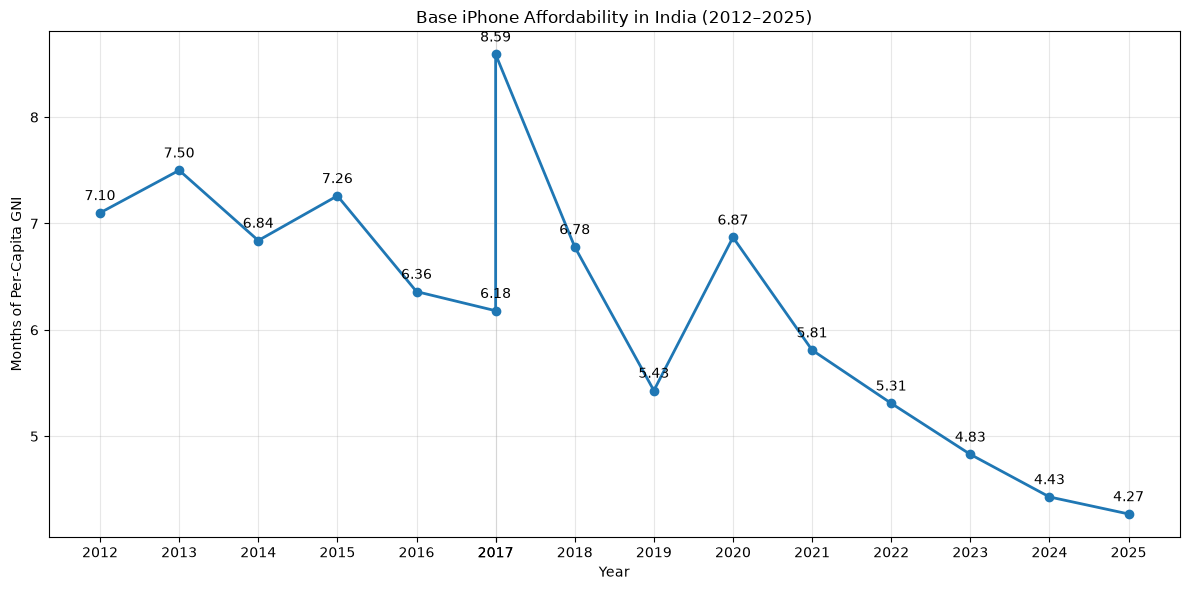

In [23]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))

plt.plot(
    df['Year'],
    df['Affordability_Months'],
    marker='o',
    linewidth=2
)

# Show every year on the x-axis
plt.xticks(df['Year'])

# Add exact value above every point
for x, y in zip(df['Year'], df['Affordability_Months']):
    plt.text(x, y + 0.12, f'{y:.2f}', ha='center')

plt.xlabel('Year')
plt.ylabel('Months of Per-Capita GNI')
plt.title('Base iPhone Affordability in India (2012–2025)')

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()


In [24]:
iphone_growth = (
    (df['Indian_Launch_price INR'].iloc[-1] /
     df['Indian_Launch_price INR'].iloc[0]) - 1
) * 100

gni_growth = (
    (df['GNI Per Capita'].iloc[-1] /
     df['GNI Per Capita'].iloc[0]) - 1
) * 100

print(f"iPhone price growth: {iphone_growth:.2f}%")
print(f"GNI per capita growth: {gni_growth:.2f}%")

iPhone price growth: 82.20%
GNI per capita growth: 203.24%


In [25]:
df['iPhone_Index'] = (
    df['Indian_Launch_price INR'] /
    df['Indian_Launch_price INR'].iloc[0]
) * 100

df['GNI_Index'] = (
    df['GNI Per Capita'] /
    df['GNI Per Capita'].iloc[0]
) * 100

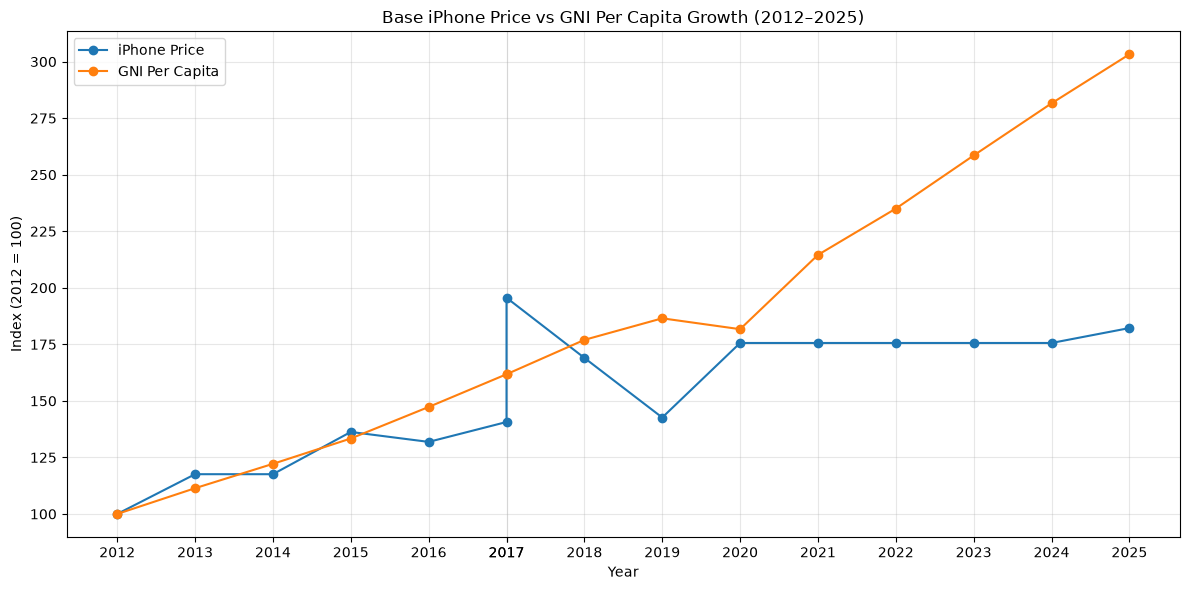

In [26]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))

plt.plot(df['Year'], df['iPhone_Index'], marker='o', label='iPhone Price')
plt.plot(df['Year'], df['GNI_Index'], marker='o', label='GNI Per Capita')

plt.xticks(df['Year'])

plt.xlabel('Year')
plt.ylabel('Index (2012 = 100)')
plt.title('Base iPhone Price vs GNI Per Capita Growth (2012–2025)')

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [27]:
import pandas as pd

base = pd.read_csv('base_iphone.csv')
gni = pd.read_csv('gni.csv')
premium = pd.read_csv('premium_iphone.csv')

print("Base:", base.shape)
print("GNI:", gni.shape)
print("Premium:", premium.shape)

Base: (47, 3)
GNI: (15, 2)
Premium: (8, 3)


In [28]:

import os

os.chdir(r'C:\Users\anann\Downloads')

print(os.getcwd())

C:\Users\anann\Downloads


In [4]:
income = pd.read_csv('income_india.csv')
income.head()

,YEAR,NATIONAL INCOME,TOP 10%SHARE,BOTTOM 50%SHARE,TOP 10% AVERAGE INCOME,BOTTOM 50% AVERAGE INCOME,OVERALL AVERAGE INCOME
0,2011,"₹100,364.00",0.5517,0.1373,"₹553,708.19","₹27,559.95","₹100,364.00"
1,2012,"₹111,231.00",0.5603,0.1346,"₹623,227.29","₹29,943.39","₹111,231.00"
2,2013,"₹122,120.00",0.5627,0.1339,"₹687,169.24","₹32,703.74","₹122,120.00"
3,2014,"₹131,973.00",0.5713,0.1313,"₹753,961.75","₹34,656.11","₹131,973.00"
4,2015,"₹143,851.00",0.5777,0.1297,"₹831,027.23","₹37,314.95","₹143,851.00"


In [5]:
income.columns

Index(['YEAR', 'NATIONAL INCOME', 'TOP 10%SHARE', 'BOTTOM 50%SHARE',
       'TOP 10% AVERAGE INCOME', 'BOTTOM 50% AVERAGE INCOME',
       'OVERALL AVERAGE INCOME'],
      dtype='str')

In [6]:
income['YEAR'] = pd.to_numeric(income['YEAR'], errors='coerce')

income['NATIONAL INCOME'] = (
    income['NATIONAL INCOME']
    .astype(str)
    .str.replace('₹', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

income['TOP 10% AVERAGE INCOME'] = (
    income['TOP 10% AVERAGE INCOME']
    .astype(str)
    .str.replace('₹', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

income['BOTTOM 50% AVERAGE INCOME'] = (
    income['BOTTOM 50% AVERAGE INCOME']
    .astype(str)
    .str.replace('₹', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

income['OVERALL AVERAGE INCOME'] = (
    income['OVERALL AVERAGE INCOME']
    .astype(str)
    .str.replace('₹', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

income.head()

,YEAR,NATIONAL INCOME,TOP 10%SHARE,BOTTOM 50%SHARE,TOP 10% AVERAGE INCOME,BOTTOM 50% AVERAGE INCOME,OVERALL AVERAGE INCOME
0,2011,100364.0,0.5517,0.1373,553708.19,27559.95,100364.0
1,2012,111231.0,0.5603,0.1346,623227.29,29943.39,111231.0
2,2013,122120.0,0.5627,0.1339,687169.24,32703.74,122120.0
3,2014,131973.0,0.5713,0.1313,753961.75,34656.11,131973.0
4,2015,143851.0,0.5777,0.1297,831027.23,37314.95,143851.0


In [29]:
df_rq6 = df.merge(
    income,
    left_on='Year',
    right_on='YEAR',
    how='inner'
)

df_rq6.head()

,iPhone,Year,Indian_Launch_price INR,GNI Per Capita,Affordability_Months,iPhone_Index,GNI_Index,YEAR,NATIONAL INCOME,TOP 10%SHARE,BOTTOM 50%SHARE,TOP 10% AVERAGE INCOME,BOTTOM 50% AVERAGE INCOME,OVERALL AVERAGE INCOME
0,iPhone 5,2012,45500.0,76854.98,7.10,100.000000,100.000000,2012,111231.0,0.5603,0.1346,623227.29,29943.39,111231.0
1,iPhone 5s,2013,53500.0,85610.32,7.50,117.582418,111.392027,2013,122120.0,0.5627,0.1339,687169.24,32703.74,122120.0
2,iPhone 6,2014,53500.0,93886.64,6.84,117.582418,122.160776,2014,131973.0,0.5713,0.1313,753961.75,34656.11,131973.0
3,iPhone 6s,2015,62000.0,102498.82,7.26,136.263736,133.366530,2015,143851.0,0.5777,0.1297,831027.23,37314.95,143851.0
4,iPhone 7,2016,60000.0,113213.53,6.36,131.868132,147.307995,2016,157480.0,0.5923,0.1256,932754.04,39558.98,157480.0


In [30]:
df_rq6['Bottom_50_Affordability_Months'] = (
    df_rq6['Indian_Launch_price INR']
    / df_rq6['BOTTOM 50% AVERAGE INCOME']
) * 12

df_rq6['Overall_Affordability_Months'] = (
    df_rq6['Indian_Launch_price INR']
    / df_rq6['OVERALL AVERAGE INCOME']
) * 12

df_rq6['Top_10_Affordability_Months'] = (
    df_rq6['Indian_Launch_price INR']
    / df_rq6['TOP 10% AVERAGE INCOME']
) * 12

df_rq6[
    [
        'Year',
        'iPhone',
        'Bottom_50_Affordability_Months',
        'Overall_Affordability_Months',
        'Top_10_Affordability_Months'
    ]
].round(2)

,Year,iPhone,Bottom_50_Affordability_Months,Overall_Affordability_Months,Top_10_Affordability_Months
0,2012,iPhone 5,18.23,4.91,0.88
1,2013,iPhone 5s,19.63,5.26,0.93
2,2014,iPhone 6,18.52,4.86,0.85
3,2015,iPhone 6s,19.94,5.17,0.90
4,2016,iPhone 7,18.20,4.57,0.77
5,2017,iPhone 8,18.11,4.49,0.75
6,2017,iPhone X,25.18,6.24,1.04
7,2018,iPhone XR,19.27,4.94,0.84
8,2019,iPhone 11,15.22,3.98,0.68
9,2020,iPhone 12,18.36,5.04,0.87


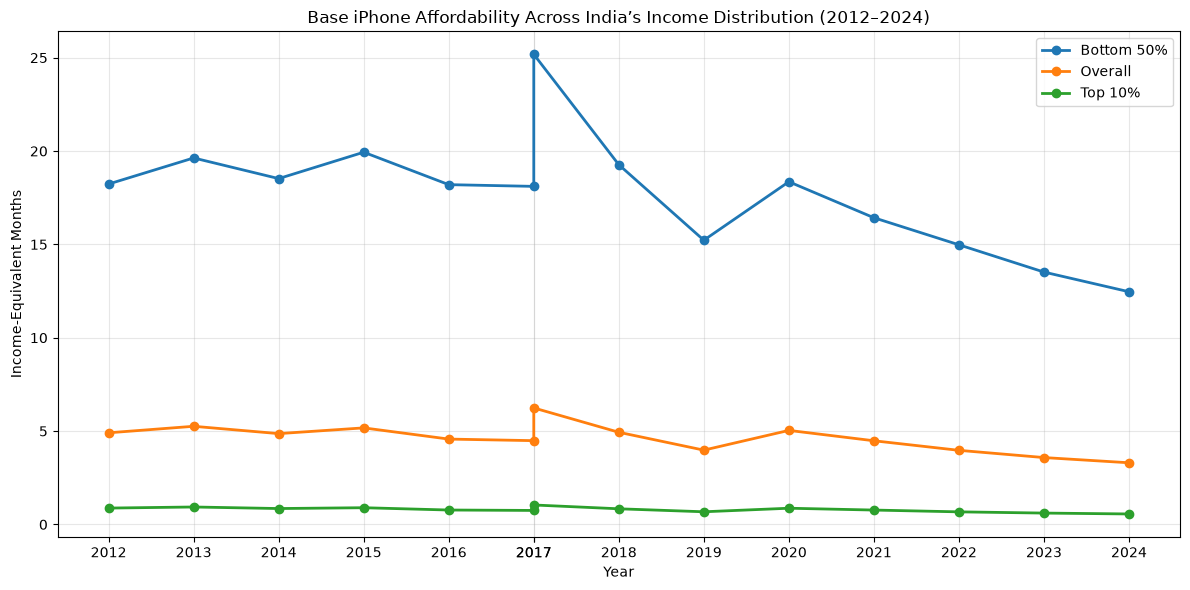

In [31]:
plt.figure(figsize=(12, 6))

plt.plot(
    df_rq6['Year'],
    df_rq6['Bottom_50_Affordability_Months'],
    marker='o',
    linewidth=2,
    label='Bottom 50%'
)

plt.plot(
    df_rq6['Year'],
    df_rq6['Overall_Affordability_Months'],
    marker='o',
    linewidth=2,
    label='Overall'
)

plt.plot(
    df_rq6['Year'],
    df_rq6['Top_10_Affordability_Months'],
    marker='o',
    linewidth=2,
    label='Top 10%'
)

plt.xticks(df_rq6['Year'])
plt.xlabel('Year')
plt.ylabel('Income-Equivalent Months')
plt.title('Base iPhone Affordability Across India’s Income Distribution (2012–2024)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [32]:
premium.head()

,iPhone,Year,India_Launch_Price_INR
0,iPhone 11 Pro Max,2019,109900
1,iPhone 12 Pro Max,2020,129900
2,iPhone 13 Pro Max,2021,129900
3,iPhone 14 Pro Max,2022,139900
4,iPhone 15 Pro Max,2023,159900


In [33]:
premium.columns

Index(['iPhone', 'Year', 'India_Launch_Price_INR'], dtype='str')

In [34]:
premium_rq6 = premium.merge(
    income,
    left_on='Year',
    right_on='YEAR',
    how='inner'
)

premium_rq6.head()

,iPhone,Year,India_Launch_Price_INR,YEAR,NATIONAL INCOME,TOP 10%SHARE,BOTTOM 50%SHARE,TOP 10% AVERAGE INCOME,BOTTOM 50% AVERAGE INCOME,OVERALL AVERAGE INCOME
0,iPhone 11 Pro Max,2019,109900,2019,195705.0,0.5870,0.1307,1148788.35,51157.29,195705.0
1,iPhone 12 Pro Max,2020,129900,2020,190352.0,0.5802,0.1372,1104422.30,52232.59,190352.0
2,iPhone 13 Pro Max,2021,129900,2021,213940.0,0.5819,0.1364,1244916.86,58362.83,213940.0
3,iPhone 14 Pro Max,2022,139900,2022,241549.0,0.5889,0.1325,1422482.06,64010.49,241549.0
4,iPhone 15 Pro Max,2023,159900,2023,267654.0,0.5889,0.1325,1576214.41,70928.31,267654.0


In [35]:
premium_rq6['Bottom_50_Affordability_Months'] = (
    premium_rq6['India_Launch_Price_INR']
    / premium_rq6['BOTTOM 50% AVERAGE INCOME']
) * 12

premium_rq6['Overall_Affordability_Months'] = (
    premium_rq6['India_Launch_Price_INR']
    / premium_rq6['OVERALL AVERAGE INCOME']
) * 12

premium_rq6['Top_10_Affordability_Months'] = (
    premium_rq6['India_Launch_Price_INR']
    / premium_rq6['TOP 10% AVERAGE INCOME']
) * 12

premium_rq6[
    [
        'Year',
        'iPhone',
        'Bottom_50_Affordability_Months',
        'Overall_Affordability_Months',
        'Top_10_Affordability_Months'
    ]
].round(2)

,Year,iPhone,Bottom_50_Affordability_Months,Overall_Affordability_Months,Top_10_Affordability_Months
0,2019,iPhone 11 Pro Max,25.78,6.74,1.15
1,2020,iPhone 12 Pro Max,29.84,8.19,1.41
2,2021,iPhone 13 Pro Max,26.71,7.29,1.25
3,2022,iPhone 14 Pro Max,26.23,6.95,1.18
4,2023,iPhone 15 Pro Max,27.05,7.17,1.22
5,2024,iPhone 16 Pro Max,22.60,5.99,1.02


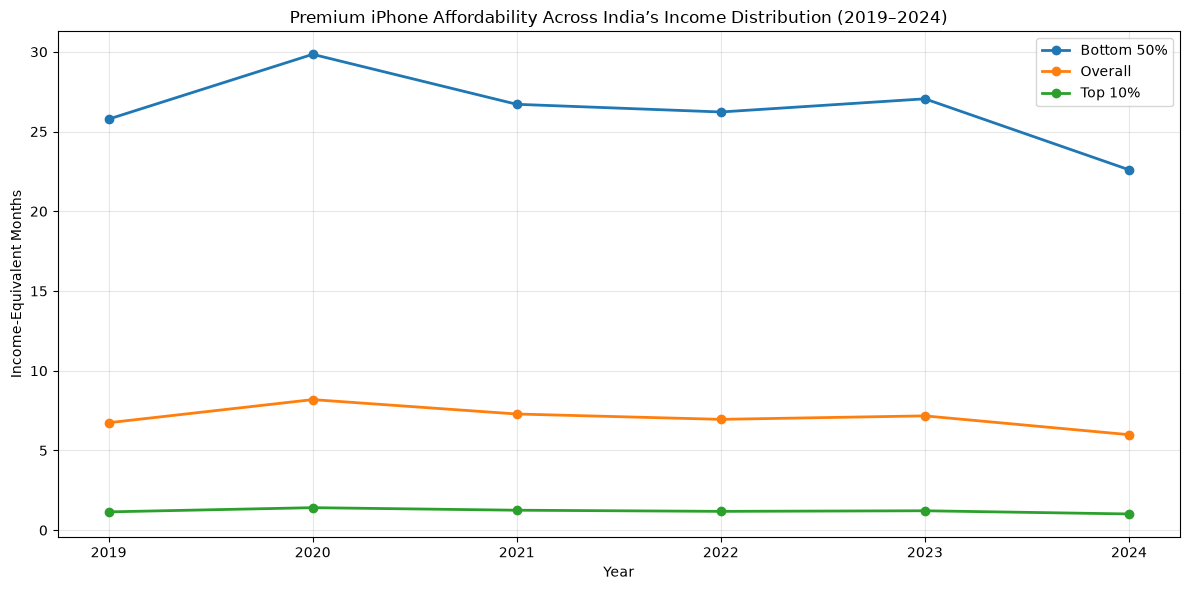

In [36]:
plt.figure(figsize=(12, 6))

plt.plot(
    premium_rq6['Year'],
    premium_rq6['Bottom_50_Affordability_Months'],
    marker='o',
    linewidth=2,
    label='Bottom 50%'
)

plt.plot(
    premium_rq6['Year'],
    premium_rq6['Overall_Affordability_Months'],
    marker='o',
    linewidth=2,
    label='Overall'
)

plt.plot(
    premium_rq6['Year'],
    premium_rq6['Top_10_Affordability_Months'],
    marker='o',
    linewidth=2,
    label='Top 10%'
)

plt.xticks(premium_rq6['Year'])
plt.xlabel('Year')
plt.ylabel('Income-Equivalent Months')
plt.title('Premium iPhone Affordability Across India’s Income Distribution (2019–2024)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [37]:
ml_data = premium_rq6[
    [
        'Year',
        'India_Launch_Price_INR',
        'BOTTOM 50% AVERAGE INCOME',
        'Bottom_50_Affordability_Months'
    ]
].copy()

ml_data

,Year,India_Launch_Price_INR,BOTTOM 50% AVERAGE INCOME,Bottom_50_Affordability_Months
0,2019,109900,51157.29,25.779317
1,2020,129900,52232.59,29.843437
2,2021,129900,58362.83,26.708780
3,2022,139900,64010.49,26.226951
4,2023,159900,70928.31,27.052668
5,2024,144900,76925.53,22.603679


In [38]:
ml_data['Years_Since_2019'] = ml_data['Year'] - 2019

ml_data

,Year,India_Launch_Price_INR,BOTTOM 50% AVERAGE INCOME,Bottom_50_Affordability_Months,Years_Since_2019
0,2019,109900,51157.29,25.779317,0
1,2020,129900,52232.59,29.843437,1
2,2021,129900,58362.83,26.708780,2
3,2022,139900,64010.49,26.226951,3
4,2023,159900,70928.31,27.052668,4
5,2024,144900,76925.53,22.603679,5


In [39]:
X = ml_data[['Years_Since_2019']]
y = ml_data['Bottom_50_Affordability_Months']

print("Feature (X):")
print(X)

print("\nTarget (y):")
print(y)

Feature (X):
   Years_Since_2019
0                 0
1                 1
2                 2
3                 3
4                 4
5                 5

Target (y):
0    25.779317
1    29.843437
2    26.708780
3    26.226951
4    27.052668
5    22.603679
Name: Bottom_50_Affordability_Months, dtype: float64


In [48]:
print("ML test working")

Training years:
[2019 2020 2021 2022]

Testing years:
[2023 2024]


In [49]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


In [50]:
y_pred = model.predict(X_test)

print("Actual affordability:")
print(y_test.values)

print("\nPredicted affordability:")
print(y_pred.round(2))

Actual affordability:
[27.05266769 22.60367917]

Predicted affordability:
[26.69 26.51]


In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f} months")
print(f"RMSE: {rmse:.2f} months")
print(f"R²: {r2:.2f}")

MAE: 2.13 months
RMSE: 2.78 months
R²: -0.56


In [52]:
final_model = LinearRegression()

final_model.fit(X, y)

print("Final model trained on all historical data.")

Final model trained on all historical data.


In [53]:
income_ml = income[['YEAR', 'BOTTOM 50% AVERAGE INCOME']].copy()

income_ml = income_ml.sort_values('YEAR')

income_ml

,YEAR,BOTTOM 50% AVERAGE INCOME
0,2011,27559.95
1,2012,29943.39
2,2013,32703.74
3,2014,34656.11
4,2015,37314.95
5,2016,39558.98
6,2017,42411.22
7,2018,47890.95
8,2019,51157.29
9,2020,52232.59


In [54]:
from sklearn.linear_model import LinearRegression

income_model = LinearRegression()

X_income = income_ml[['YEAR']]
y_income = income_ml['BOTTOM 50% AVERAGE INCOME']

income_model.fit(X_income, y_income)

print("Income model trained successfully.")

Income model trained successfully.


In [55]:
income_2026 = pd.DataFrame({
    'YEAR': [2026]
})

predicted_income_2026 = income_model.predict(income_2026)

print(f"Projected bottom 50% average income in 2026: ₹{predicted_income_2026[0]:,.2f}")

Projected bottom 50% average income in 2026: ₹78,467.40


In [56]:
foldable_price_2026 = 299900

foldable_affordability_2026 = (
    foldable_price_2026 / predicted_income_2026[0]
) * 12

print(
    f"2026 foldable iPhone affordability for bottom 50%: "
    f"{foldable_affordability_2026:.2f} months"
)

2026 foldable iPhone affordability for bottom 50%: 45.86 months


In [57]:
X_2030 = pd.DataFrame({
    'Years_Since_2019': [11]
})

X_2030

,Years_Since_2019
0,11


In [58]:
prediction_2030 = final_model.predict(X_2030)

print(
    f"Projected premium iPhone affordability for the bottom 50% in 2030: "
    f"{prediction_2030[0]:.2f} months"
)

Projected premium iPhone affordability for the bottom 50% in 2030: 20.36 months


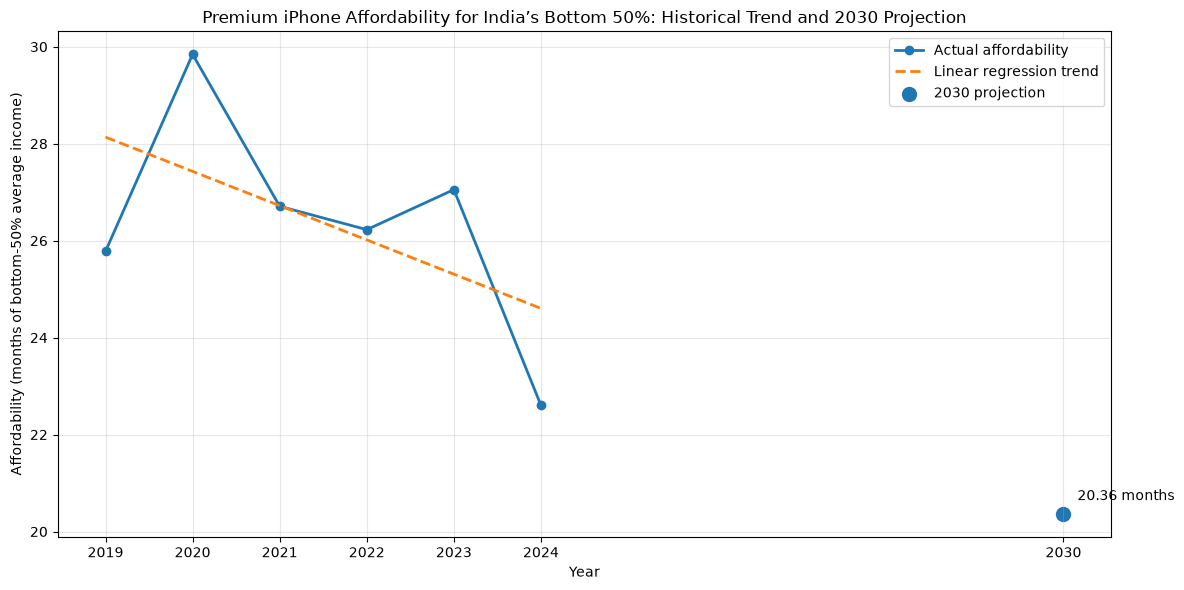

In [59]:
# ML Visualization: Historical Affordability + 2030 Projection

import matplotlib.pyplot as plt

# Historical fitted values
historical_prediction = final_model.predict(X)

# 2030 prediction
prediction_2030_value = prediction_2030[0]

plt.figure(figsize=(12, 6))

# Actual historical affordability
plt.plot(
    ml_data['Year'],
    y,
    marker='o',
    linewidth=2,
    label='Actual affordability'
)

# Model fitted trend
plt.plot(
    ml_data['Year'],
    historical_prediction,
    linestyle='--',
    linewidth=2,
    label='Linear regression trend'
)

# 2030 projection
plt.scatter(
    2030,
    prediction_2030_value,
    s=100,
    label='2030 projection'
)

# Label the 2030 point
plt.annotate(
    f'{prediction_2030_value:.2f} months',
    (2030, prediction_2030_value),
    xytext=(10, 10),
    textcoords='offset points'
)

plt.xlabel('Year')
plt.ylabel('Affordability (months of bottom-50% average income)')
plt.title('Premium iPhone Affordability for India’s Bottom 50%: Historical Trend and 2030 Projection')
plt.xticks(list(ml_data['Year']) + [2030])
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()